In [1]:
import hmmlearn
print(hmmlearn.__version__)

0.3.3


In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import time
import warnings
from hmmlearn.hmm import GaussianHMM
warnings.filterwarnings('ignore')
print("Libraries loaded")

Libraries loaded


In [3]:
#A&S MODEL
class AvellanedaStoikov:
    def __init__(self, gamma=0.1, kappa=1.5):
        self.gamma=gamma
        self.kappa=kappa
    def reservation_price(self, s, q, sigma, T_t):
        return s-q*self.gamma*sigma**2*T_t
    def optimal_spread(self, sigma, T_t):
        inv_term=self.gamma*sigma**2*T_t
        book_term=(2/self.gamma)*np.log(1+self.gamma/self.kappa)
        return inv_term+book_term
    def quotes(self, s, q, sigma, T_t):
        r=self.reservation_price(s, q, sigma, T_t)
        delta=self.optimal_spread(sigma, T_t)
        bid=r-delta/2
        ask=r+delta/2
        return bid, ask, r, delta

print("AvellanedaStoikov class ready")

AvellanedaStoikov class ready


In [4]:
#PORTFOLIO CLASS
class Portfolio:
    def __init__(self, cash=100000):
        self.cash=cash
        self.inventory=0
        self.trades=[]
    def buy(self, price):
        self.cash-=price
        self.inventory+=1
        self.trades.append(("Buy", price, datetime.now()))
    def sell(self, price):
        self.cash+=price
        self.inventory-=1
        self.trades.append(("SELL", price, datetime.now()))
    def wealth(self, price):
        return self.cash + self.inventory*price

print("Portfolio class ready")

Portfolio class ready


In [5]:
class TransactionCosts:
    def __init__(self):
        self.stt        = 0.00025   # 0.025% on sell side (realistic NSE STT for intraday)
        self.exchange   = 0.0000345 # 0.00345% per trade
        self.brokerage  = 0
        self.total_cost = 0

    def compute(self, price, side):
        exchange_fee    = price * self.exchange
        stt             = price * self.stt if side == "SELL" else 0
        cost            = exchange_fee + stt
        self.total_cost += cost
        return cost

In [6]:
#FETCH DATA AND FIT HMM 
TICKER="HDFCBANK.NS"
ticker=yf.Ticker(TICKER)
df=ticker.history(period="5d", interval="1m")

df["mid"]=(df["High"]+ df["Low"])/2
df["high"]=df["High"]
df["low"]=df["Low"]
df["returns"]=np.log(df["mid"]/df["mid"].shift(1))
df["vol"]=df["returns"].rolling(30).std()
df=df.dropna()

print(f"Fetched {len(df)} rows for {TICKER}")

# FIT HMM
features=np.column_stack([
    df["returns"].values,
    df["vol"].values
])

hmm=GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)
hmm.fit(features)
regimes=hmm.predict(features)
df["regime"]=regimes

print(f"HMM fitted. Unique regimes found: {np.unique(regimes)}")

#Label regimes by Volatility

regime_vols={}
for r in np.unique(regimes):
    mask=regimes==r
    regime_vols[r]=df["vol"].values[mask].mean()

sorted_regimes=sorted(regime_vols, key=regime_vols.get)
regime_map={
    sorted_regimes[0]:0,
    sorted_regimes[1]:1,
    sorted_regimes[2]:2,
}
df["regime"]=df["regime"].map(regime_map)
regimes=df["regime"].values

regime_names={
    0: "Low Vol / Mean Reverting",
    1: "High Vol/Trending",
    2: "Crisis/Extreme"
}
for r, name in regime_names.items():
    pct=(regimes==r).mean()*100
    avg_vol=df["vol"].values[regimes==r].mean()
    print(f"Regime {r}-{name}: {pct:.1f}% of time | avg sigma={avg_vol:.5f}")


Fetched 1526 rows for HDFCBANK.NS
HMM fitted. Unique regimes found: [0 1 2]
Regime 0-Low Vol / Mean Reverting: 45.1% of time | avg sigma=0.00043
Regime 1-High Vol/Trending: 45.5% of time | avg sigma=0.00043
Regime 2-Crisis/Extreme: 9.4% of time | avg sigma=0.00153


In [7]:
#A-S PARAMETERS PER REGIME
# Parameters switch based on detected regime
REGIME_PARAMS = {
    0: {"gamma": 0.05, "kappa": 15.0, "name": "Low Vol"},   # tight spread
    1: {"gamma": 0.20, "kappa": 3.0,  "name": "High Vol"},  # wide spread
    2: {"gamma": 0.50, "kappa": 1.0,  "name": "Crisis"},    # very wide
}

print("Regime parameters:")
for r, p in REGIME_PARAMS.items():
    m = AvellanedaStoikov(gamma=p["gamma"], kappa=p["kappa"])
    spread = m.optimal_spread(sigma=0.0002, T_t=0.5)
    print(f"  Regime {r} ({p['name']}): gamma={p['gamma']} kappa={p['kappa']} → spread≈Rs.{spread:.4f}")

Regime parameters:
  Regime 0 (Low Vol): gamma=0.05 kappa=15.0 → spread≈Rs.0.1331
  Regime 1 (High Vol): gamma=0.2 kappa=3.0 → spread≈Rs.0.6454
  Regime 2 (Crisis): gamma=0.5 kappa=1.0 → spread≈Rs.1.6219


In [8]:
# ── Parameters ────────────────────────────────────────────────────────────────
prices  = df["mid"].values
highs   = df["high"].values
lows    = df["low"].values
WINDOW  = 30
INV_LIM = 10

# ── Regime Parameters (recalibrated) ─────────────────────────────────────────
REGIME_PARAMS = {
    0: {"gamma": 0.1,  "kappa": 5.0,  "name": "Low Vol"},
    1: {"gamma": 0.2,  "kappa": 2.0,  "name": "High Vol"},
    2: {"gamma": 0.5,  "kappa": 0.5,  "name": "Crisis"},
}

portfolio = Portfolio(cash=100000)
tc        = TransactionCosts()
history   = []
n         = len(prices)

for t in range(WINDOW, n):
    s      = prices[t]
    regime = regimes[t]

    # ── Switch A-S parameters based on regime ─────────────────────────────────
    params = REGIME_PARAMS[regime]
    model  = AvellanedaStoikov(gamma=params["gamma"], kappa=params["kappa"])

    # ── Rolling sigma ─────────────────────────────────────────────────────────
    returns = np.diff(np.log(prices[t-WINDOW:t]))
    sigma   = max(np.std(returns), 1e-6)

    # ── Time remaining ────────────────────────────────────────────────────────
    T_t = max(1 - t/n, 0.05)

    # ── Current inventory for quote generation ────────────────────────────────
    q = portfolio.inventory

    # ── Generate quotes ───────────────────────────────────────────────────────
    bid, ask, r, delta = model.quotes(s, q, sigma, T_t)

    # ── Fill check against previous candle high/low ───────────────────────────
    if t > WINDOW:
        prev_low  = lows[t-1]
        prev_high = highs[t-1]

        # BUY — only if inventory strictly below limit
        if prev_low <= bid:
            if portfolio.inventory < INV_LIM:
                cost = tc.compute(bid, "BUY")
                portfolio.cash -= cost
                portfolio.buy(bid)
        curr_inv=portfolio.inventory

        # SELL — only if inventory strictly below limit
        if prev_high >= ask:
            if portfolio.inventory > -INV_LIM:
                cost = tc.compute(ask, "SELL")
                portfolio.cash -= cost
                portfolio.sell(ask)

    # ── Record history ────────────────────────────────────────────────────────
    history.append({
        "t"         : t,
        "price"     : s,
        "bid"       : bid,
        "ask"       : ask,
        "r"         : r,
        "delta"     : delta,
        "sigma"     : sigma,
        "inventory" : portfolio.inventory,
        "wealth"    : portfolio.wealth(s),
        "regime"    : regime,
    })

hist      = pd.DataFrame(history)
gross_pnl = portfolio.wealth(prices[-1]) - 100000

print(f"Backtest done")
print(f"Total Trades     : {len(portfolio.trades)}")
print(f"Gross P&L        : Rs.{gross_pnl:+.2f}")
print(f"Transaction Costs: Rs.{tc.total_cost:.2f}")
print(f"Net P&L          : Rs.{gross_pnl - tc.total_cost:+.2f}")
print(f"Max inventory    : {hist['inventory'].max()}")
print(f"Min inventory    : {hist['inventory'].min()}")
print(f"Total buys       : {sum(1 for t in portfolio.trades if t[0] == 'Buy')}")
print(f"Total sells      : {sum(1 for t in portfolio.trades if t[0] == 'SELL')}")

Backtest done
Total Trades     : 1104
Gross P&L        : Rs.+359.35
Transaction Costs: Rs.138.55
Net P&L          : Rs.+220.80
Max inventory    : 10
Min inventory    : -10
Total buys       : 548
Total sells      : 556


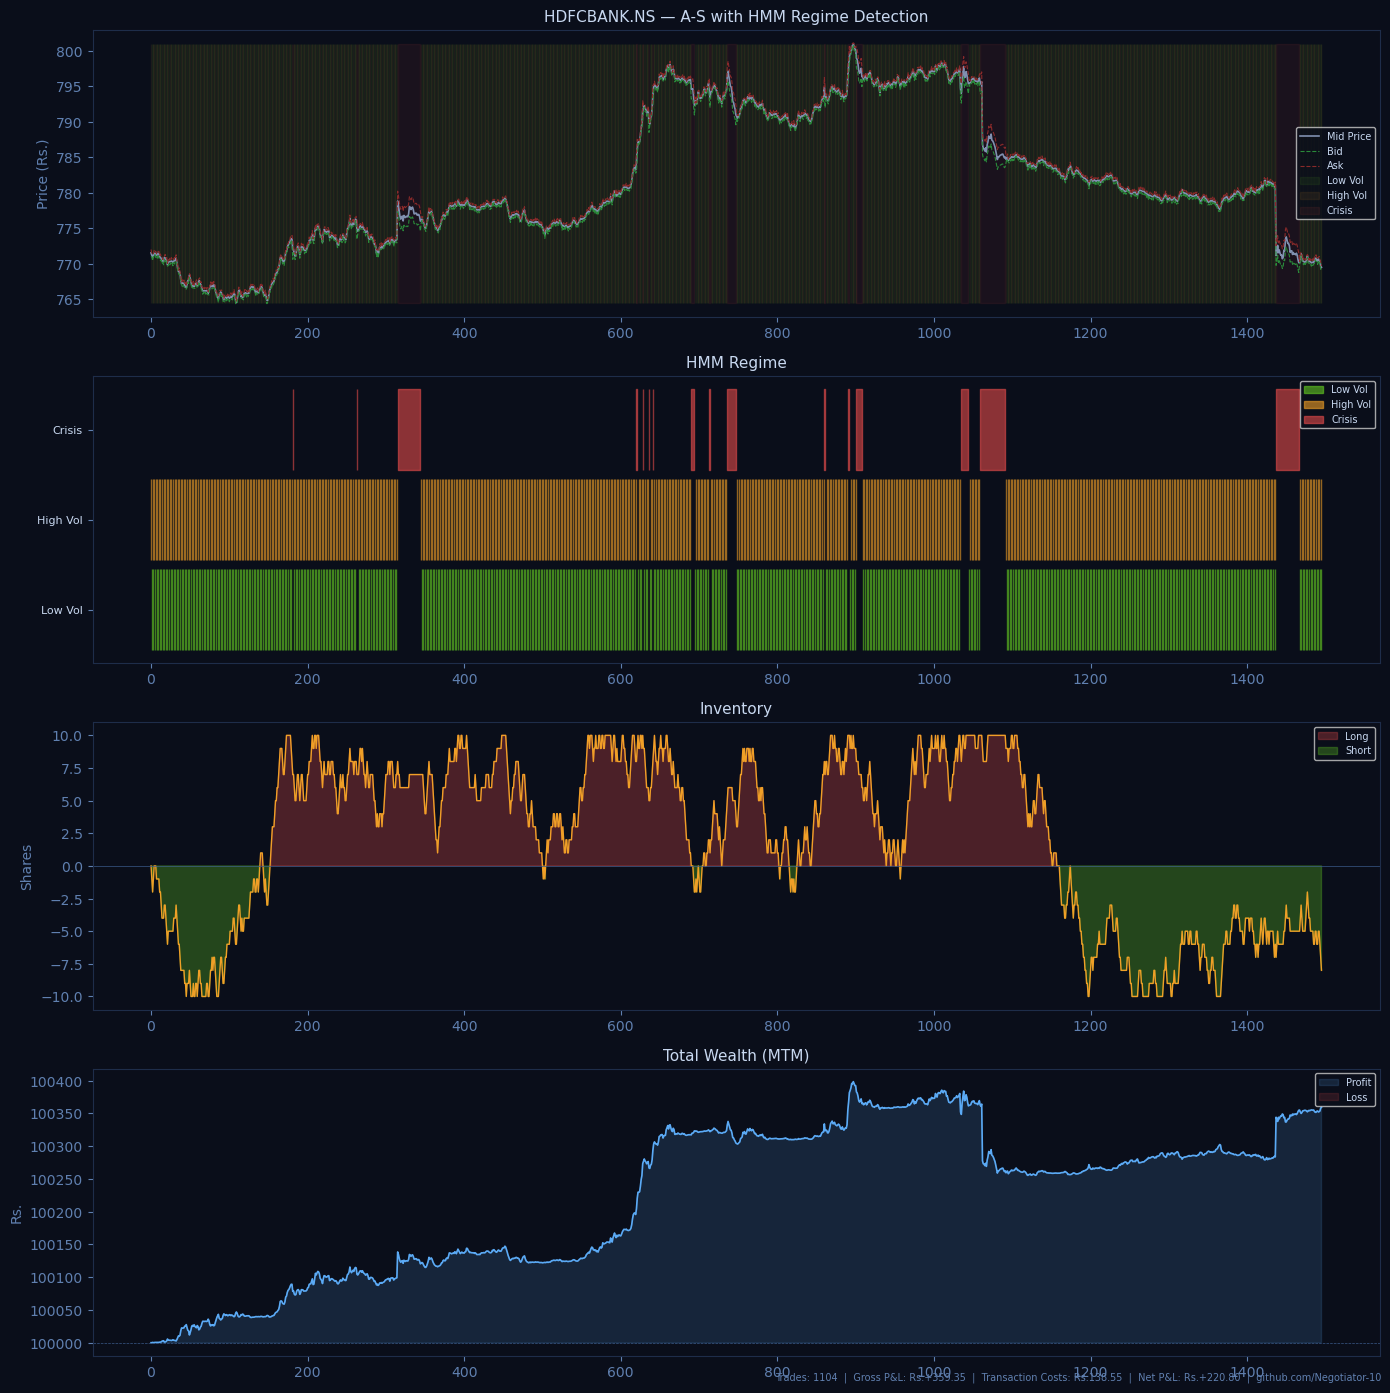

Chart saved as as_hmm_hdfcbank.png


In [9]:
REGIME_COLORS = {0: "#63c922", 1: "#ef9f27", 2: "#e24b4a"}
REGIME_LABELS = {0: "Low Vol", 1: "High Vol", 2: "Crisis"}

fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.patch.set_facecolor('#0a0e1a')
for ax in axes:
    ax.set_facecolor('#0a0e1a')
    ax.tick_params(colors='#6080b0')
    ax.spines[:].set_color('#1e2d4a')

# Chart 1 — Price with regime background
ax = axes[0]
ax.plot(hist["price"], color="#8090b0", lw=1.2, label="Mid Price")
ax.plot(hist["bid"],   color="#2a8a3a", lw=0.8, label="Bid", linestyle="--")
ax.plot(hist["ask"],   color="#8a2a2a", lw=0.8, label="Ask", linestyle="--")
for regime, color in REGIME_COLORS.items():
    mask = hist["regime"] == regime
    ax.fill_between(hist.index, hist["price"].min(), hist["price"].max(),
                    where=mask, alpha=0.08, color=color,
                    label=REGIME_LABELS[regime])
ax.set_title(f"{TICKER} — A-S with HMM Regime Detection", color="#c8d8f0", fontsize=11)
ax.legend(facecolor="#0a0e1a", labelcolor="#c8d8f0", fontsize=7)
ax.set_ylabel("Price (Rs.)", color="#6080b0")

# Chart 2 — Regime
ax = axes[1]
for regime, color in REGIME_COLORS.items():
    mask = hist["regime"] == regime
    ax.fill_between(hist.index, regime, regime+0.9,
                    where=mask, color=color, alpha=0.6,
                    label=REGIME_LABELS[regime])
ax.set_yticks([0.45, 1.45, 2.45])
ax.set_yticklabels(["Low Vol", "High Vol", "Crisis"], color="#c8d8f0", fontsize=8)
ax.set_title("HMM Regime", color="#c8d8f0", fontsize=11)
ax.legend(facecolor="#0a0e1a", labelcolor="#c8d8f0", fontsize=7)

# Chart 3 — Inventory
ax = axes[2]
ax.plot(hist["inventory"], color="#ef9f27", lw=1)
ax.axhline(0, color="#3a5a8a", lw=0.5)
ax.fill_between(hist.index, hist["inventory"], 0,
                where=hist["inventory"] > 0, color="#e24b4a", alpha=0.3, label="Long")
ax.fill_between(hist.index, hist["inventory"], 0,
                where=hist["inventory"] < 0, color="#63c922", alpha=0.3, label="Short")
ax.set_title("Inventory", color="#c8d8f0", fontsize=11)
ax.legend(facecolor="#0a0e1a", labelcolor="#c8d8f0", fontsize=7)
ax.set_ylabel("Shares", color="#6080b0")

# Chart 4 — Wealth
ax = axes[3]
start = hist["wealth"].iloc[0]
ax.plot(hist["wealth"], color="#5baaf5", lw=1.2)
ax.axhline(start, color="#3a5a8a", lw=0.5, linestyle="--")
ax.fill_between(hist.index, hist["wealth"], start,
                where=hist["wealth"] >= start, color="#5baaf5", alpha=0.15, label="Profit")
ax.fill_between(hist.index, hist["wealth"], start,
                where=hist["wealth"] <  start, color="#e24b4a", alpha=0.15, label="Loss")
ax.set_title("Total Wealth (MTM)", color="#c8d8f0", fontsize=11)
ax.legend(facecolor="#0a0e1a", labelcolor="#c8d8f0", fontsize=7)
ax.set_ylabel("Rs.", color="#6080b0")

# Footer
fig.text(0.99, 0.01,
    f"Trades: {len(portfolio.trades)}  |  "
    f"Gross P&L: Rs.{gross_pnl:+.2f}  |  "
    f"Transaction Costs: Rs.{tc.total_cost:.2f}  |  "
    f"Net P&L: Rs.{gross_pnl - tc.total_cost:+.2f}  |  "
    f"github.com/Negotiator-10",
    color="#6080b0", fontsize=7, ha="right")

plt.tight_layout()
plt.savefig("as_hmm_hdfcbank.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as as_hmm_hdfcbank.png")

In [10]:
# ── HMM Live Paper Trader ─────────────────────────────────────────────────────
model_live     = None   # will be set dynamically per regime
portfolio_live = Portfolio(cash=100000)
tc_live        = TransactionCosts()

price_buffer = []
high_buffer  = []
low_buffer   = []

INTERVAL = 30
INV_LIM  = 10

print("HMM Live Paper Trader started. Press Stop to end.\n")

try:
    while True:
        now = datetime.now()

        # ── Market hours check ────────────────────────────────────────────────
        open_min  = 9  * 60 + 15
        close_min = 15 * 60 + 30
        curr_min  = now.hour * 60 + now.minute

        if curr_min < open_min or curr_min > close_min:
            print(f"[{now.strftime('%H:%M:%S')}] Market closed. Waiting 60s...")
            time.sleep(60)
            continue

        # ── Fetch price ───────────────────────────────────────────────────────
        data = yf.Ticker("HDFCBANK.NS").history(period="1d", interval="1m")

        if data.empty:
            print("No data. Retrying in 30s...")
            time.sleep(30)
            continue

        last_high = float(data["High"].iloc[-2])
        last_low  = float(data["Low"].iloc[-2])
        s         = (last_high + last_low) / 2

        price_buffer.append(s)
        high_buffer.append(last_high)
        low_buffer.append(last_low)

        print(f"[{now.strftime('%H:%M:%S')}] Price: Rs.{s:.2f}  buffer={len(price_buffer)}")

        # ── Warmup ────────────────────────────────────────────────────────────
        if len(price_buffer) < 30:
            print(f"  Warming up {len(price_buffer)}/30...")
            time.sleep(INTERVAL)
            continue

        # ── Rolling returns and sigma ─────────────────────────────────────────
        rets  = np.diff(np.log(price_buffer[-30:]))
        sigma = max(np.std(rets), 1e-6)
        vol   = sigma

        # ── Detect current regime using HMM ───────────────────────────────────
        live_features = np.column_stack([
            np.append(rets, rets[-1]),  # pad to match length
            np.full(30, vol)
        ])
        live_regime_raw = hmm.predict(live_features)[-1]
        live_regime     = regime_map[live_regime_raw]

        # ── Switch A-S parameters based on regime ─────────────────────────────
        params     = REGIME_PARAMS[live_regime]
        model_live = AvellanedaStoikov(
            gamma=params["gamma"],
            kappa=params["kappa"]
        )

        # ── Time remaining ────────────────────────────────────────────────────
        T_t = max(1 - (curr_min - open_min) / (close_min - open_min), 0.05)

        # ── Generate quotes ───────────────────────────────────────────────────
        q = portfolio_live.inventory
        bid, ask, r, delta = model_live.quotes(s, q, sigma, T_t)

        # ── Fill check ────────────────────────────────────────────────────────
        if len(price_buffer) >= 2:
            prev_low  = low_buffer[-2]
            prev_high = high_buffer[-2]

            if prev_low <= bid:
                if portfolio_live.inventory < INV_LIM:
                    cost = tc_live.compute(bid, "BUY")
                    portfolio_live.cash -= cost
                    portfolio_live.buy(bid)
                    print(f"  BUY  @ Rs.{bid:.2f}  inv={portfolio_live.inventory:+d}  "
                          f"regime={params['name']}")

            if prev_high >= ask:
                if portfolio_live.inventory > -INV_LIM:
                    cost = tc_live.compute(ask, "SELL")
                    portfolio_live.cash -= cost
                    portfolio_live.sell(ask)
                    print(f"  SELL @ Rs.{ask:.2f}  inv={portfolio_live.inventory:+d}  "
                          f"regime={params['name']}")

        # ── Hard close-out at 3:25 PM ─────────────────────────────────────────
        if curr_min >= (15 * 60 + 25):
            if portfolio_live.inventory != 0:
                print(f"\n[{now.strftime('%H:%M:%S')}] 3:25 PM — Flattening position...")
                if portfolio_live.inventory > 0:
                    for _ in range(portfolio_live.inventory):
                        cost = tc_live.compute(s, "SELL")
                        portfolio_live.cash -= cost
                        portfolio_live.sell(s)
                else:
                    for _ in range(abs(portfolio_live.inventory)):
                        cost = tc_live.compute(s, "BUY")
                        portfolio_live.cash -= cost
                        portfolio_live.buy(s)
                print(f"  Position flattened. inv={portfolio_live.inventory}")

        # ── Dashboard ─────────────────────────────────────────────────────────
        pnl       = portfolio_live.wealth(s) - 100000
        gross_pnl = pnl + tc_live.total_cost
        print(
            f"[{now.strftime('%H:%M:%S')}]  "
            f"S=Rs.{s:.2f}  "
            f"bid=Rs.{bid:.2f}  ask=Rs.{ask:.2f}  "
            f"regime={params['name']}  "
            f"delta=Rs.{delta:.4f}  "
            f"sigma={sigma:.5f}  "
            f"T={T_t:.2f}  "
            f"inv={q:+d}  "
            f"costs=Rs.{tc_live.total_cost:.2f}  "
            f"Net P&L=Rs.{pnl:+.2f}"
        )

        time.sleep(INTERVAL)

except KeyboardInterrupt:
    s_final = price_buffer[-1] if price_buffer else 0
    pnl     = portfolio_live.wealth(s_final) - 100000

    print("\n" + "="*55)
    print("   SESSION SUMMARY — HMM REGIME ADAPTIVE TRADER")
    print("="*55)
    print(f"   Total Trades     : {len(portfolio_live.trades)}")
    print(f"   Inventory        : {portfolio_live.inventory:+d} shares")
    print(f"   Transaction Costs: Rs.{tc_live.total_cost:.2f}")
    print(f"   Gross P&L        : Rs.{pnl + tc_live.total_cost:+.2f}")
    print(f"   Net P&L          : Rs.{pnl:+.2f}")
    print("="*55)

HMM Live Paper Trader started. Press Stop to end.

[10:13:33] Price: Rs.769.65  buffer=1
  Warming up 1/30...
[10:14:03] Price: Rs.769.65  buffer=2
  Warming up 2/30...
[10:14:33] Price: Rs.769.42  buffer=3
  Warming up 3/30...
[10:15:03] Price: Rs.769.02  buffer=4
  Warming up 4/30...
[10:15:34] Price: Rs.769.02  buffer=5
  Warming up 5/30...
[10:16:04] Price: Rs.768.70  buffer=6
  Warming up 6/30...
[10:16:34] Price: Rs.768.70  buffer=7
  Warming up 7/30...
[10:17:04] Price: Rs.768.30  buffer=8
  Warming up 8/30...
[10:17:35] Price: Rs.768.30  buffer=9
  Warming up 9/30...
[10:18:05] Price: Rs.768.28  buffer=10
  Warming up 10/30...
[10:18:35] Price: Rs.768.28  buffer=11
  Warming up 11/30...
[10:19:05] Price: Rs.767.80  buffer=12
  Warming up 12/30...
[10:19:35] Price: Rs.767.80  buffer=13
  Warming up 13/30...
[10:20:06] Price: Rs.767.27  buffer=14
  Warming up 14/30...
[10:20:36] Price: Rs.767.27  buffer=15
  Warming up 15/30...
[10:21:06] Price: Rs.767.30  buffer=16
  Warming up 